# EC1036 - Inteligência Computacional
## Tópico: Classificação com K-Nearest Neighbors (k-NN)

## 1. O Problema da Classificação

A essência da classificação é: dado um **vetor $X$** com $N$ parâmetros (características), precisamos encontrar sua **classe $y$** entre as $Y$ possíveis etiquetas (rótulos).

* **Entrada ($X$):** Atributos mensuráveis (ex: Comprimento e Peso de um peixe).
* **Saída ($y$):** A categoria à qual o objeto pertence.
* **Conjunto de Treinamento:** É a nossa "base de conhecimento", composta por exemplos onde já sabemos a resposta correta.
* **Avaliação:** Medimos o sucesso do classificador pela taxa de erro (ou misclassification rate) em exemplos "não vistos" (conjunto de teste).


## 2. O Funcionamento do Nearest Neighbor (NN)

O classificador do vizinho mais próximo é o modelo mais simples possível: ele armazena toda a sequência de treinamento na memória. Quando um novo dado chega, busca o exemplo armazenado com a menor distância e atribui ao novo dado a mesma classe desse vizinho.

**Lógica do Algoritmo:**
1. **Carregar dados:** Treino e teste são carregados na memória.
2. **Busca exaustiva:** Para cada item de teste, percorremos todo o treino calculando a distância.
3. **Atualização:** Se a distância atual for a menor encontrada, guardamos esse vizinho.
4. **Decisão:** O classificador retorna o rótulo do vizinho mais próximo.

---

**Generalizando para k-NN:**

O problema de usar apenas o vizinho mais próximo ($K=1$) é que ele é muito sensível a outliers (pontos fora da curva, que podem estar errados ou ser ruído).

* **O que é o $K$:** Escolhemos um número inteiro (geralmente ímpar, como 3 ou 5) de vizinhos, um valor ímpar para $K$ retira a chance de empate entre classes (por exemplo, 2 votos a 2 quando $K=4$), deixando a decisão mais estável e direta.

* **Regra de decisão:** O classificador retorna o rótulo mais popular (moda) entre esses $K$ vizinhos.

* **Robustez:** Com $K > 1$, o modelo ignora ruídos isolados, criando regiões de decisão mais suaves e confiáveis.

---

**Otimização: reduzindo o custo computacional**

Como o k-NN é um classificador "lazy" (preguiçoso), ele não processa nada até o momento da consulta. Isso gera um custo computacional proibitivo quando o conjunto de treino é muito grande. Para resolver isso, podemos utilizar o algoritmo K-means para "resumir" as classes. Em vez de guardar 1.000 pontos da Classe A, aplicamos o K-means para encontrar os $K$ centros (centróides) que representam bem esses dados. No caso de $K=1$ no K-means, cada classe passaria a ser representada apenas por sua média aritmética.

## 3. Distâncias e Normas


A escolha da métrica de distância define a sensibilidade do modelo. As mais comuns são:

* **Euclidiana (Norma $L_2$):** Corresponde ao quadrado do erro vetorial: $d(y,z) = ||y-z||^2$.
* **Manhattan (Norma $L_1$):** Soma dos valores absolutos: $||x||_1 = \sum |x_i|$.
* **Cosseno:** Mede a similaridade pelo ângulo entre vetores: $sim(A,B) = \frac{A \cdot B}{||A|| ||B||}$.


## 4. Demonstração em python

1. Define os dados de treino (comprimento e peso) e seus rótulos.
2. Cria um ponto de teste e calcula sua distância para cada ponto de treino.
3. Escolhe o menor valor de distância para identificar o vizinho mais próximo ($K=1$).

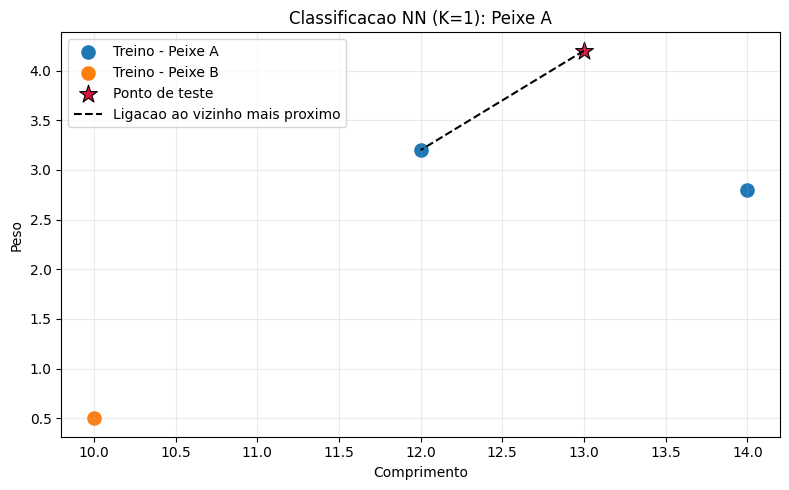

Classe prevista para o ponto de teste: Peixe A


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dados de Treino: [Comprimento, Peso] 
X_train = np.array([
    [12, 3.2], 
    [10, 0.5], 
    [14, 2.8]
])
y_train = np.array(['Peixe A', 'Peixe B', 'Peixe A']) # Rótulos 

# Novo peixe (Exemplo não visto) 
x_test = np.array([13, 4.2])

# Cálculo da Distância Euclidiana (Quadrado da norma)
distancias = np.sum((X_train - x_test)**2, axis=1)

# Encontrando o índice do menor valor
indice_vizinho = np.argmin(distancias)
classe_prevista = y_train[indice_vizinho]

# Cores por classe
cores = {"Peixe A": "tab:blue", "Peixe B": "tab:orange"}

plt.figure(figsize=(8, 5))

# Plota os pontos de treino por classe
for classe in np.unique(y_train):
    mask = y_train == classe
    plt.scatter(
        X_train[mask, 0],
        X_train[mask, 1],
        s=90,
        c=cores[classe],
        label=f"Treino - {classe}"
    )

# Plota o ponto de teste
plt.scatter(
    x_test[0],
    x_test[1],
    s=180,
    marker="*",
    c="crimson",
    edgecolors="black",
    linewidths=0.8,
    label="Ponto de teste"
 )

# Destaca o vizinho mais proximo
vizinho = X_train[indice_vizinho]
plt.plot(
    [x_test[0], vizinho[0]],
    [x_test[1], vizinho[1]],
    "k--",
    lw=1.5,
    label="Ligacao ao vizinho mais proximo"
 )

plt.title(f"Classificacao NN (K=1): {classe_prevista}")
plt.xlabel("Comprimento")
plt.ylabel("Peso")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Classe prevista para o ponto de teste: {classe_prevista}")

## Exemplo 

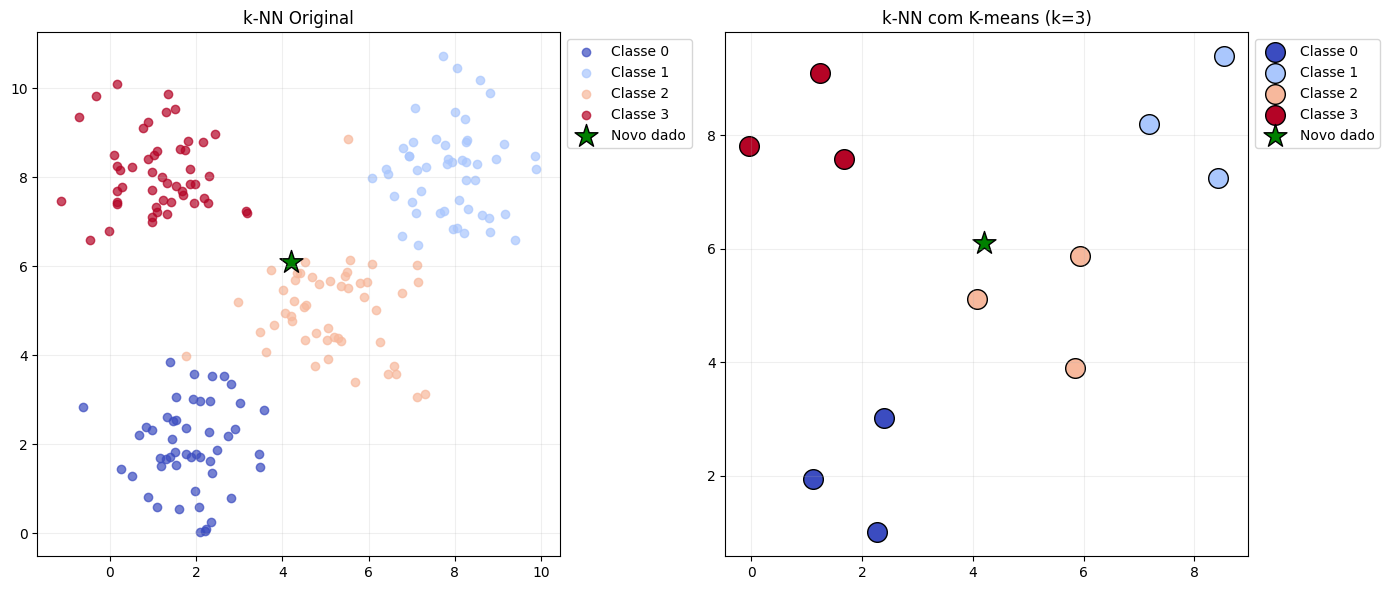

Novo dado: [4.2 6.1]
Classe prevista no k-NN original: 2
Classe prevista no k-NN otimizado: 2
Reducao de dados: de 200 para 12 pontos


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

# 1. Gerando dados fictícios (Classe 0 a 3)
np.random.seed(42)
# Criamos 4 grupos em locais diferentes do gráfico
cluster_0 = np.random.randn(50, 2) + [2, 2]   
cluster_1 = np.random.randn(50, 2) + [8, 8]   
cluster_2 = np.random.randn(50, 2) + [5, 5]   
cluster_3 = np.random.randn(50, 2) + [1, 8]   

X_train = np.vstack([cluster_0, cluster_1, cluster_2, cluster_3])
y_train = np.array([0] * 50 + [1] * 50 + [2] * 50 + [3] * 50)
nomes_classes = ['Classe 0', 'Classe 1', 'Classe 2', 'Classe 3']

# 2. Otimização com K-means: Reduzindo 50 pontos de cada classe para apenas 3 centros
n_centros = 3
clusters = [cluster_0, cluster_1, cluster_2, cluster_3]
centros_list = []

for c in clusters:
    km = KMeans(n_clusters=n_centros, random_state=0).fit(c)
    centros_list.append(km.cluster_centers_)

X_resumo = np.vstack(centros_list)
y_resumo = np.array([0] * n_centros + [1] * n_centros + [2] * n_centros + [3] * n_centros)

# 3. Treino dos modelos
knn_full = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
knn_resumo = KNeighborsClassifier(n_neighbors=1).fit(X_resumo, y_resumo)

# 4. Ponto de Teste (Novo dado)
x_novo = np.array([[4.2, 6.1]])
pred_full = knn_full.predict(x_novo)[0]
pred_resumo = knn_resumo.predict(x_novo)[0]

# 5. Visualização
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.get_cmap("coolwarm")
cores = [cmap(i) for i in np.linspace(0, 1, 4)]

# --- Gráfico 1: k-NN Original ---
for i in range(4):
    indices = np.where(y_train == i)
    ax1.scatter(X_train[indices, 0], X_train[indices, 1], label=nomes_classes[i], color=cores[i], alpha=0.7)

ax1.scatter(x_novo[:, 0], x_novo[:, 1], color="green", s=300, marker="*", edgecolors="black", 
            label=f"Novo dado")
ax1.set_title("k-NN Original")
ax1.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax1.grid(alpha=0.2)

# --- Gráfico 2: k-NN com Resumo (K-means) ---
for i in range(4):
    indices = np.where(y_resumo == i)
    ax2.scatter(X_resumo[indices, 0], X_resumo[indices, 1], label=nomes_classes[i], color=cores[i], s=200, edgecolors='k')

ax2.scatter(x_novo[:, 0], x_novo[:, 1], color="green", s=300, marker="*", edgecolors="black", 
            label=f"Novo dado")
ax2.set_title(f"k-NN com K-means (k={n_centros})")
ax2.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Novo dado: {x_novo[0]}")
print(f"Classe prevista no k-NN original: {pred_full}")
print(f"Classe prevista no k-NN otimizado: {pred_resumo}")
print(f"Reducao de dados: de {len(X_train)} para {len(X_resumo)} pontos")